# ECOD (Empirical Cumulative Distribution-based Outlier Detection)

This script uses the unified_dataset.csv and applies ECOD for fraud anomaly detection. ECOD is a parameter-free, highly interpretable unsupervised anomaly detection algorithm that identifies outliers based on empirical cumulative distribution functions.

Key advantages of ECOD:
- **No hyperparameters** - No tuning required
- **Highly interpretable** - Shows which features contribute to each anomaly
- **Fast and scalable** - Handles large, high-dimensional datasets
- **Research-backed** - Used in Medicare fraud detection studies

The notebook includes:
- Data preprocessing with standard scaling
- ECOD model training
- Per-feature anomaly contribution analysis
- Visualization of detected anomalies
- Model export for ensemble integration

Nulls are replaced with -1. The test data is 40% of the original data. This script takes less than 1 minute to run!

In [1]:
########################
# NOTES
#######################
#Outputting anomalies because the rest of the column is 0?

In [2]:
!pip install pyod --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.ecod import ECOD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

##  Load and Prepare Data

In [4]:
# Load the dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (140827, 67)

First few rows:


,npi,target,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplrs_median,tot_suplrs_min,tot_suplr_clms_min,tot_suplr_srvcs_min,...,tot_suplr_benes_sum_zscore_by_type,tot_suplr_srvcs_max_zscore,total_payment_zscore_by_type,bene_avg_age_zscore_by_type,bene_avg_risk_scre_zscore_by_type,submitted_to_standardized_ratio_zscore,submitted_to_standardized_ratio_zscore_by_type,claims_per_bene_zscore_by_type,services_per_bene_zscore_by_type,benes_per_supplier_zscore_by_type
0,1003000597,0,1.692306,1.692306,1.692306,1.0,3.0,3,44,5955,...,-0.275616,-0.007007,-0.008424,-0.549574,-0.210703,-0.038129,-0.154682,3.003923,4.288024,-0.187419
1,1003000597,0,23.833223,0.112054,8.331875,5.0,3.0,1,17,32,...,-0.219804,0.045155,-0.010997,-0.115403,-0.311213,-0.082280,-0.424691,1.564890,2.626744,-0.159271
2,1003000902,0,155.711788,0.087436,82.163333,5.0,2.5,1,12,12,...,-0.145469,-0.091197,-0.065875,-0.363841,0.187261,0.015906,-0.018203,-0.036876,-0.073170,-0.092180
3,1003000902,0,67.361088,0.028794,38.227500,4.0,3.0,1,11,12,...,-0.261960,-0.075164,-0.073111,-1.214294,-0.554692,0.061148,0.299657,-0.374303,0.108292,-0.098162
4,1003000902,0,40.802223,0.098643,24.145333,3.0,3.5,1,11,11,...,-0.344188,-0.088898,-0.059281,-0.835965,-0.337922,-0.029850,-0.339677,-0.049636,0.152416,-0.091872


In [5]:
# Check for missing values
print("Missing values per column (top 20):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

# Replace nulls with -1
df = df.fillna(-1)
print("\nNulls replaced with -1")

Missing values per column (top 20):
npi                                               0
submitted_charge_per_bene_pctile_by_type          0
bene_cc_ph_arthritis_v2_pct                       0
bene_cc_ph_stroke_tia_v2_pct                      0
form_count_cash_or_cash_equivalent                0
third_party_recipient_sum_individual              0
specialty_type                                    0
specialty                                         0
benes_per_supplier                                0
avg_suplr_sbmtd_chrg_mean_pctile_by_type          0
avg_suplr_sbmtd_chrg_max_pctile_by_type           0
tot_suplr_benes_sum_pctile_by_type                0
tot_suplr_srvcs_max_pctile_by_type                0
total_payment_pctile_by_type                      0
bene_avg_age_pctile_by_type                       0
bene_avg_risk_scre_pctile_by_type                 0
submitted_to_standardized_ratio_pctile_by_type    0
bene_cc_ph_ischemic_heart_v2_pct                  0
claims_per_bene_pctile_by_ty

In [6]:
# Define columns to exclude from modeling
exclude_cols = ['target', 'npi', 'year', 'Rfrg_NPI', 'covered_recipient_npi', 
                'fraud_flag', 'year_leie', 'excltype']

# Also exclude date columns
date_cols = [col for col in df.columns if 'date' in col.lower()]
exclude_cols.extend(date_cols)

# Select only numeric columns, excluding identifiers and target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Excluded columns: {[c for c in exclude_cols if c in df.columns]}")

# Create feature matrix
X = df[feature_cols].copy()

Number of feature columns: 63
Excluded columns: ['target', 'npi']


##  Train-Test Split and Scaling

In [7]:
# Split data: 60% train, 40% test
X_train, X_test, train_idx, test_idx = train_test_split(
    X, X.index, test_size=0.4, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 84496 samples
Test set size: 56331 samples


In [8]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"\nTraining data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

Features scaled using StandardScaler

Training data - Mean: -0.0000, Std: 1.0000
Test data - Mean: -0.0001, Std: 1.5005


##  ECOD Model Training

ECOD is parameter-free, so no hyperparameter tuning is required. The algorithm:
1. Estimates the empirical cumulative distribution for each feature
2. Computes tail probabilities for each data point per feature
3. Aggregates tail probabilities across features to get an anomaly score

In [9]:
# Train ECOD model
ecod = ECOD(contamination=0.001, n_jobs=-1)  # contamination only affects binary labels, not scores
ecod.fit(X_train_scaled)

print(f"Number of features: {X_train_scaled.shape[1]}")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    1.7s remaining:    5.2s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    1.8s finished


Number of features: 63


In [10]:
# Get anomaly scores for train and test sets
# Higher scores = more anomalous
train_scores = ecod.decision_function(X_train_scaled)
test_scores = ecod.decision_function(X_test_scaled)

# Get binary predictions
train_predictions = ecod.predict(X_train_scaled)  # 0 = normal, 1 = anomaly
test_predictions = ecod.predict(X_test_scaled)

print(f"Training set anomalies: {train_predictions.sum()} ({train_predictions.sum()/len(train_predictions)*100:.2f}%)")
print(f"Test set anomalies: {test_predictions.sum()} ({test_predictions.sum()/len(test_predictions)*100:.2f}%)")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.7s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.6s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.3s remaining:    0.8s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:    0.2s remaining:    0.6s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:    0.4s finished


Training set anomalies: 85 (0.10%)
Test set anomalies: 40 (0.07%)


##  Anomaly Score Distribution Analysis

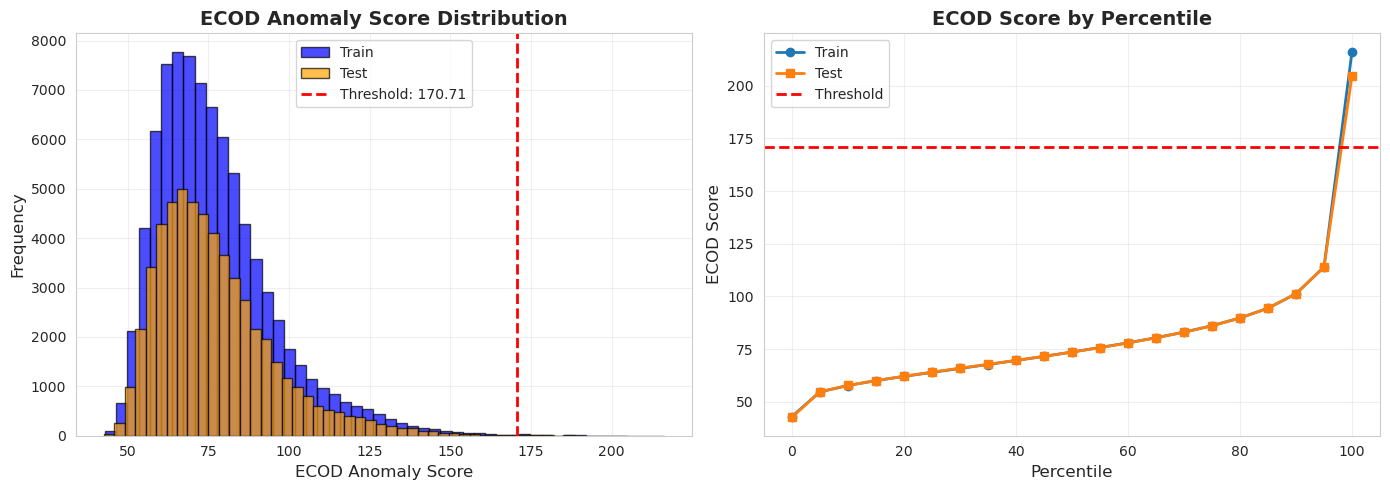

In [11]:
# Visualize anomaly score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Score distribution
axes[0].hist(train_scores, bins=50, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0].hist(test_scores, bins=50, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0].axvline(x=ecod.threshold_, color='red', linestyle='--', linewidth=2, label=f'Threshold: {ecod.threshold_:.2f}')
axes[0].set_xlabel('ECOD Anomaly Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('ECOD Anomaly Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Score percentiles
percentiles = np.arange(0, 101, 5)
train_percentile_scores = np.percentile(train_scores, percentiles)
test_percentile_scores = np.percentile(test_scores, percentiles)

axes[1].plot(percentiles, train_percentile_scores, marker='o', label='Train', linewidth=2)
axes[1].plot(percentiles, test_percentile_scores, marker='s', label='Test', linewidth=2)
axes[1].axhline(y=ecod.threshold_, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Percentile', fontsize=12)
axes[1].set_ylabel('ECOD Score', fontsize=12)
axes[1].set_title('ECOD Score by Percentile', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('ecod_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Score statistics
print("ECOD Score Statistics:")
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print(f"{'Mean':<20} {train_scores.mean():>12.4f} {test_scores.mean():>12.4f}")
print(f"{'Std':<20} {train_scores.std():>12.4f} {test_scores.std():>12.4f}")
print(f"{'Min':<20} {train_scores.min():>12.4f} {test_scores.min():>12.4f}")
print(f"{'25th Percentile':<20} {np.percentile(train_scores, 25):>12.4f} {np.percentile(test_scores, 25):>12.4f}")
print(f"{'Median':<20} {np.median(train_scores):>12.4f} {np.median(test_scores):>12.4f}")
print(f"{'75th Percentile':<20} {np.percentile(train_scores, 75):>12.4f} {np.percentile(test_scores, 75):>12.4f}")
print(f"{'95th Percentile':<20} {np.percentile(train_scores, 95):>12.4f} {np.percentile(test_scores, 95):>12.4f}")
print(f"{'99th Percentile':<20} {np.percentile(train_scores, 99):>12.4f} {np.percentile(test_scores, 99):>12.4f}")
print(f"{'Max':<20} {train_scores.max():>12.4f} {test_scores.max():>12.4f}")

ECOD Score Statistics:
Metric                      Train         Test
Mean                      77.2260      77.2208
Std                       18.5497      18.4757
Min                       42.9728      42.5653
25th Percentile           63.9185      64.0666
Median                    73.6038      73.5832
75th Percentile           86.0973      86.0225
95th Percentile          113.9433     113.9148
99th Percentile          137.6531     137.9952
Max                      216.1727     204.6549


##  Per-Feature Contribution Analysis (Explainability)

ECOD's key advantage is explainability.

In [13]:
# Get per-feature outlier scores (O matrix from ECOD)
# This shows the contribution of each feature to the final anomaly score

# ECOD stores the per-dimension outlier scores
def get_feature_contributions(ecod_model, X_scaled, feature_names):
    """
    Get per-feature anomaly contributions for ECOD.
    Returns a DataFrame with feature contributions for each sample.
    """
    # Get decision scores per feature
    # ECOD's O_ attribute contains per-dimension outlier scores for training data
    
    n_samples, n_features = X_scaled.shape
    contributions = np.zeros((n_samples, n_features))
    
    for i in range(n_features):
        feature_vals = X_scaled[:, i]
        # Compute percentile rank for each value
        from scipy import stats
        percentiles = stats.rankdata(feature_vals) / len(feature_vals)
        
        # ECOD uses tail probabilities
        # For right-skewed: use 1 - percentile
        # For left-skewed: use percentile
        skewness = stats.skew(feature_vals)
        if skewness >= 0:  # Right-skewed or symmetric
            contributions[:, i] = -np.log(1 - percentiles + 1e-10)
        else:  # Left-skewed
            contributions[:, i] = -np.log(percentiles + 1e-10)
    
    return pd.DataFrame(contributions, columns=feature_names)

# Get contributions for test set
test_contributions = get_feature_contributions(ecod, X_test_scaled, feature_cols)
print(f"Feature contributions shape: {test_contributions.shape}")

Feature contributions shape: (56331, 63)


In [14]:
# Identify top contributing features across all anomalies
anomaly_mask = test_predictions == 1
normal_mask = test_predictions == 0

# Mean contribution per feature for anomalies vs normal
anomaly_contrib_mean = test_contributions[anomaly_mask].mean()
normal_contrib_mean = test_contributions[normal_mask].mean()

# Difference shows which features drive anomaly detection
feature_importance = (anomaly_contrib_mean - normal_contrib_mean).sort_values(ascending=False)

print("Top 20 Features Contributing to Anomalies:")

for i, (feat, score) in enumerate(feature_importance.head(20).items(), 1):
    print(f"{i:2d}. {feat:<45} {score:>8.4f}")

Top 20 Features Contributing to Anomalies:
 1. tot_suplr_benes_max                             5.5912
 2. tot_suplr_benes_sum_zscore_by_type              5.2269
 3. tot_suplr_benes_sum_pctile_by_type              5.0886
 4. tot_suplr_clms_max                              4.8635
 5. benes_per_supplier                              4.4583
 6. tot_suplr_srvcs_max_zscore                      4.3096
 7. benes_per_supplier_zscore_by_type               4.0899
 8. bene_dual_cnt                                   3.7310
 9. submitted_charge_per_bene_pctile_by_type        3.5230
10. tot_suplr_clms_min                              3.4383
11. breathing_aids                                  3.3831
12. oxygen_delivery_systems_and_related_supplies    3.3068
13. tot_suplr_srvcs_min                             3.2858
14. humidifiers_and_nebulizers_with_related_equipment   3.2849
15. accessories_for_oxygen_delivery_devices         2.4991
16. bene_cc_ph_osteoporosis_v2_pct                  2.2993
17. tot_s

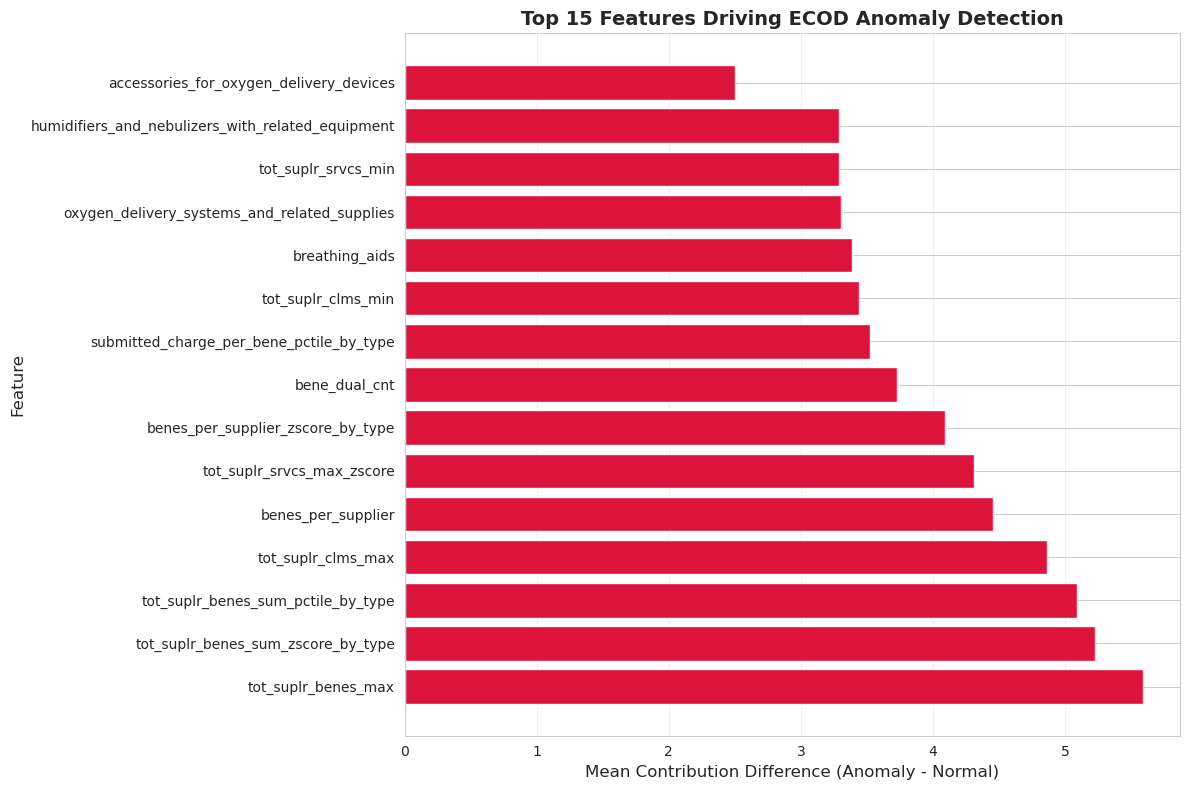

In [15]:
# Visualize top features
top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(12, 8))
colors = ['crimson' if v > 0 else 'steelblue' for v in top_features.values]
plt.barh(range(top_n), top_features.values, color=colors)
plt.yticks(range(top_n), top_features.index)
plt.xlabel('Mean Contribution Difference (Anomaly - Normal)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features Driving ECOD Anomaly Detection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# plt.savefig('ecod_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##  Visualize Anomalies with PCA

In [16]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA Explained Variance Ratio: [0.57458835 0.08378548]
Total variance explained: 65.84%


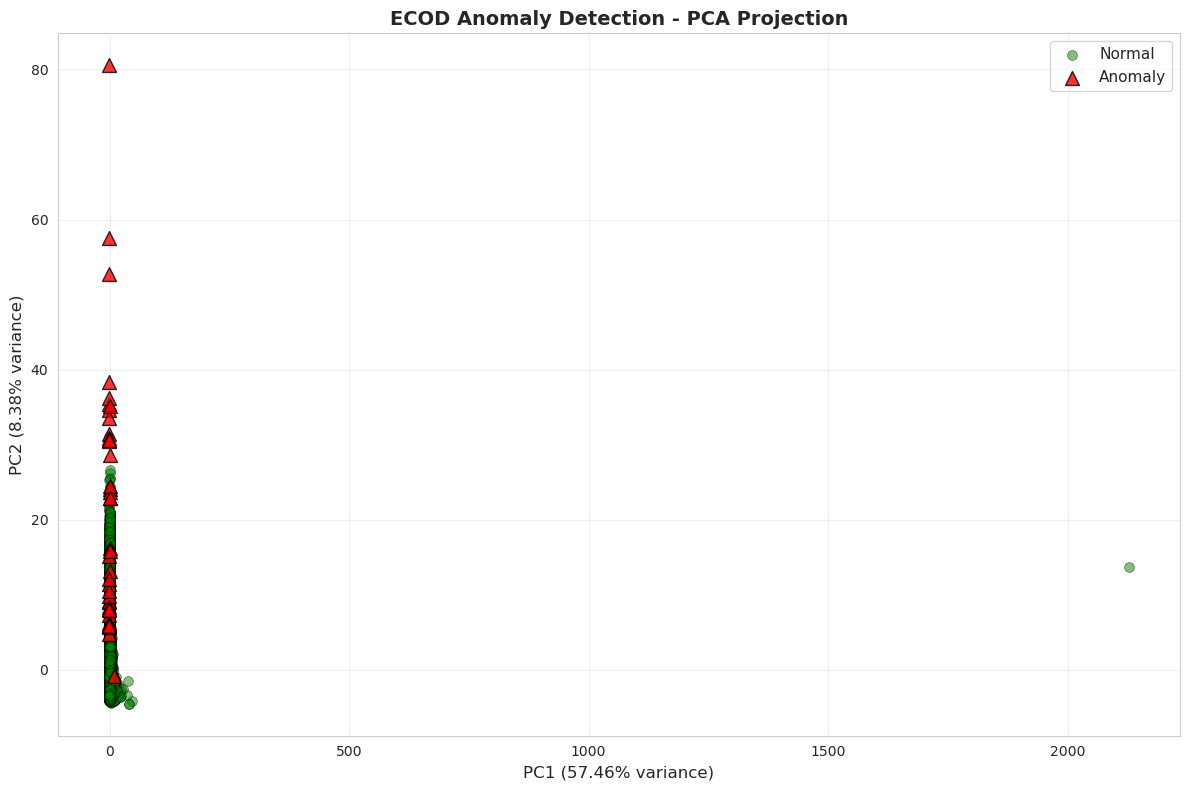

In [17]:
# Create visualization
plt.figure(figsize=(12, 8))

# Plot normal samples
normal_samples = X_test_pca[test_predictions == 0]
plt.scatter(normal_samples[:, 0], normal_samples[:, 1], 
            c='green', s=50, alpha=0.5, label='Normal', edgecolors='k', linewidth=0.5)

# Plot anomalies
anomaly_samples = X_test_pca[test_predictions == 1]
plt.scatter(anomaly_samples[:, 0], anomaly_samples[:, 1], 
            c='red', s=100, alpha=0.8, label='Anomaly', edgecolors='k', linewidth=1, marker='^')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('ECOD Anomaly Detection - PCA Projection', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('ecod_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

##  Per-Feature Tail Probability Heatmap for Top Anomalies

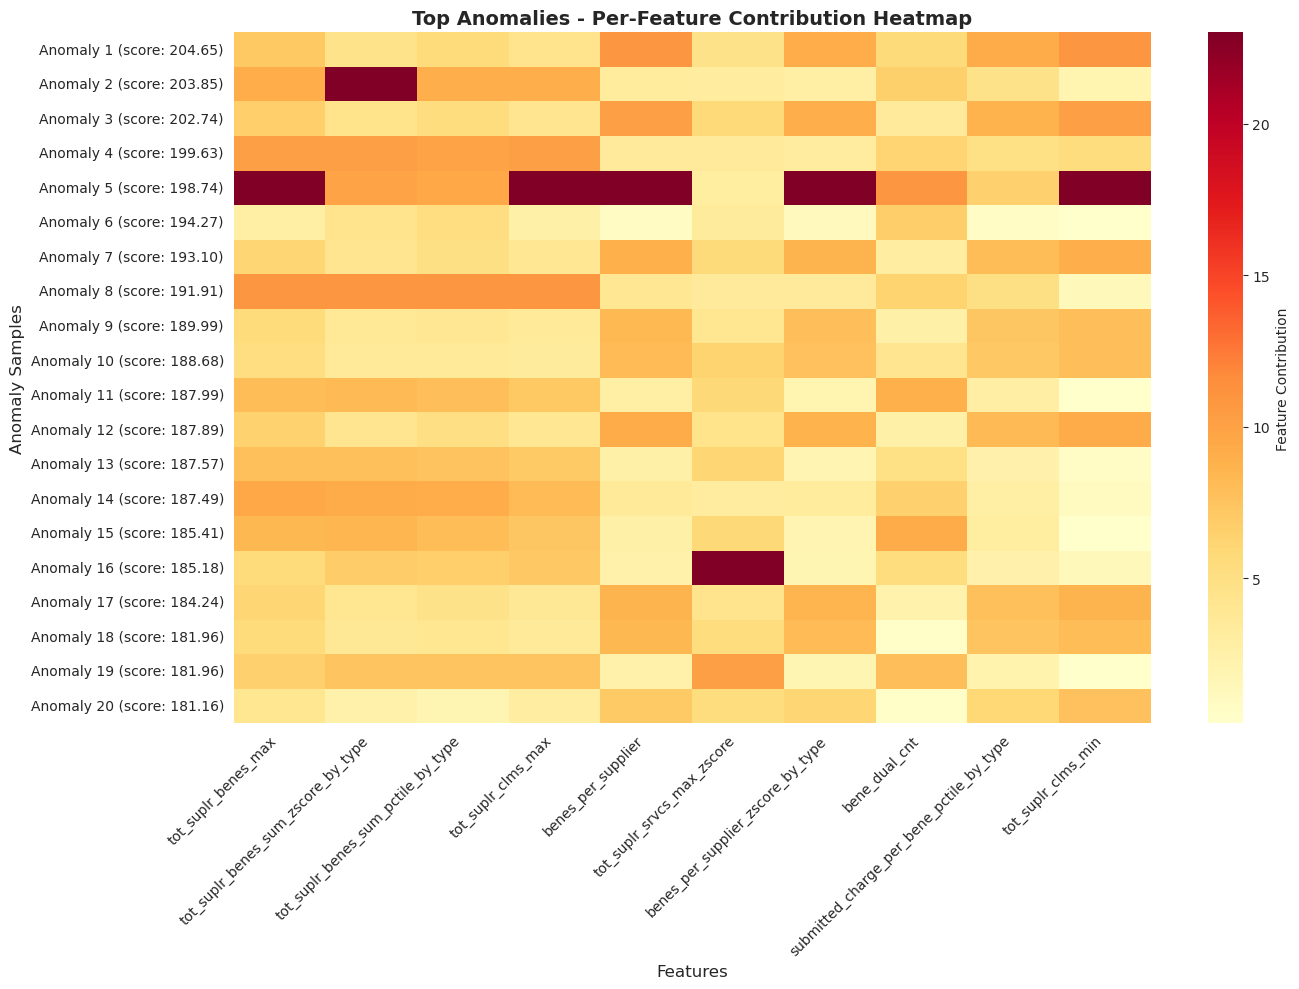

In [18]:
# Select top anomalies by highest score
n_top_anomalies = 20
top_anomaly_indices = np.argsort(test_scores)[-n_top_anomalies:][::-1]

# Get top features
top_feature_names = feature_importance.head(10).index.tolist()

# Create heatmap data
heatmap_data = test_contributions.iloc[top_anomaly_indices][top_feature_names]

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data.values, 
            xticklabels=top_feature_names, 
            yticklabels=[f"Anomaly {i+1} (score: {test_scores[idx]:.2f})" 
                         for i, idx in enumerate(top_anomaly_indices)],
            cmap='YlOrRd', 
            cbar_kws={'label': 'Feature Contribution'})
plt.title('Top Anomalies - Per-Feature Contribution Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Anomaly Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('ecod_anomaly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##  Individual Anomaly Explanation Example

In [19]:
def explain_anomaly(idx, test_scores, test_contributions, feature_cols, X_test, top_k=10):
    """
    Generate a detailed explanation for a specific anomaly.
    """
    score = test_scores[idx]
    contrib = test_contributions.iloc[idx]
    original_values = X_test.iloc[idx]
    
    # Get top contributing features
    top_contrib = contrib.sort_values(ascending=False).head(top_k)
    
    print(f"\n{'='*70}")
    print(f"ANOMALY EXPLANATION - Sample Index: {idx}")
    print(f"{'='*70}")
    print(f"\nOverall ECOD Anomaly Score: {score:.4f}")
    print(f"Percentile Rank: {(test_scores < score).sum() / len(test_scores) * 100:.1f}%")
    print(f"\nTop {top_k} Contributing Features:")
    print("-"*70)
    print(f"{'Feature':<40} {'Contribution':>12} {'Raw Value':>12}")
    print("-"*70)
    
    for feat, contrib_val in top_contrib.items():
        raw_val = original_values[feat]
        print(f"{feat:<40} {contrib_val:>12.4f} {raw_val:>12.2f}")
    
    print(f"{'='*70}\n")

# Explain top 3 anomalies
print("\nDETAILED ANOMALY EXPLANATIONS")

for i, idx in enumerate(top_anomaly_indices[:3]):
    explain_anomaly(idx, test_scores, test_contributions, feature_cols, X_test)


DETAILED ANOMALY EXPLANATIONS

ANOMALY EXPLANATION - Sample Index: 50515

Overall ECOD Anomaly Score: 204.6549
Percentile Rank: 100.0%

Top 10 Contributing Features:
----------------------------------------------------------------------
Feature                                  Contribution    Raw Value
----------------------------------------------------------------------
tot_suplr_clms_min                            10.9390       613.00
benes_per_supplier                            10.9390       613.00
submitted_charge_per_bene_pctile_by_type       9.3296         0.01
benes_per_supplier_zscore_by_type              9.1472        26.04
tot_suplr_srvcs_min                            7.2254    137600.00
tot_suplr_benes_max                            7.1895       613.00
bene_dual_cnt                                  5.6686        84.00
tot_suplr_benes_sum_pctile_by_type             5.5967        99.63
bene_cc_bh_schizo_oth_psy_v1_pct               5.0147         0.02
tot_suplr_srvcs_max_z

##  Summary Statistics

In [20]:

print("ECOD FRAUD DETECTION SUMMARY")

print(f"\nModel Configuration:")
print(f"  - Algorithm: ECOD (Empirical Cumulative Distribution-based Outlier Detection)")
print(f"  - Hyperparameters: None (parameter-free algorithm)")
print(f"  - Contamination (for labeling): {ecod.contamination}")
print(f"  - Features Used: {len(feature_cols)}")

print(f"\nDataset:")
print(f"  - Total Samples: {len(df)}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Test Samples: {len(X_test)}")

print(f"\nAnomaly Detection Results (Test Set):")
print(f"  - Normal Samples: {(test_predictions == 0).sum()} ({(test_predictions == 0).sum()/len(test_predictions)*100:.2f}%)")
print(f"  - Anomalous Samples: {(test_predictions == 1).sum()} ({(test_predictions == 1).sum()/len(test_predictions)*100:.2f}%)")
print(f"  - Decision Threshold: {ecod.threshold_:.4f}")

print(f"\nTop 5 Features Driving Anomaly Detection:")
for i, (feat, score) in enumerate(feature_importance.head(5).items(), 1):
    print(f"  {i}. {feat:<45} (contribution: {score:+.4f})")

print(f"\nPCA Visualization:")
print(f"  - Variance Explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - Variance Explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  - Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")



ECOD FRAUD DETECTION SUMMARY

Model Configuration:
  - Algorithm: ECOD (Empirical Cumulative Distribution-based Outlier Detection)
  - Hyperparameters: None (parameter-free algorithm)
  - Contamination (for labeling): 0.001
  - Features Used: 63

Dataset:
  - Total Samples: 140827
  - Training Samples: 84496
  - Test Samples: 56331

Anomaly Detection Results (Test Set):
  - Normal Samples: 56291 (99.93%)
  - Anomalous Samples: 40 (0.07%)
  - Decision Threshold: 170.7071

Top 5 Features Driving Anomaly Detection:
  1. tot_suplr_benes_max                           (contribution: +5.5912)
  2. tot_suplr_benes_sum_zscore_by_type            (contribution: +5.2269)
  3. tot_suplr_benes_sum_pctile_by_type            (contribution: +5.0886)
  4. tot_suplr_clms_max                            (contribution: +4.8635)
  5. benes_per_supplier                            (contribution: +4.4583)

PCA Visualization:
  - Variance Explained by PC1: 57.46%
  - Variance Explained by PC2: 8.38%
  - Total Va

##  Save Model and Artifacts for Ensemble Integration

In [21]:
# Save the trained model
joblib.dump(ecod, 'ecod_model.pkl')
print("Model saved to 'ecod_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'ecod_scaler.pkl')
print("Scaler saved to 'ecod_scaler.pkl'")

# Save reference scores for z-score normalization in ensemble
reference_data = {
    'train_scores': train_scores,
    'train_mean': train_scores.mean(),
    'train_std': train_scores.std(),
    'threshold': ecod.threshold_,
    'feature_cols': feature_cols,
    'feature_importance': feature_importance.to_dict()
}
joblib.dump(reference_data, 'ecod_reference_scores.pkl')
print("Reference scores saved to 'ecod_reference_scores.pkl'")

print(f"\nReference Statistics:")
print(f"  - Training Score Mean: {reference_data['train_mean']:.4f}")
print(f"  - Training Score Std: {reference_data['train_std']:.4f}")

Model saved to 'ecod_model.pkl'
Scaler saved to 'ecod_scaler.pkl'
Reference scores saved to 'ecod_reference_scores.pkl'

Reference Statistics:
  - Training Score Mean: 77.2260
  - Training Score Std: 18.5497


In [22]:
# Export predictions with scores
output_df = X_test.copy()
output_df['ecod_score'] = test_scores
output_df['ecod_anomaly'] = test_predictions

# Add top feature contributions
for feat in feature_importance.head(5).index:
    output_df[f'contrib_{feat}'] = test_contributions[feat].values

# Sort by anomaly score (most anomalous first)
output_df = output_df.sort_values('ecod_score', ascending=False)

print("Top 10 Most Anomalous Samples:")
print(output_df[['ecod_score', 'ecod_anomaly']].head(10))

# Export to CSV
output_df.to_csv('ecod_predictions.csv', index=True)
print("\nPredictions exported to 'ecod_predictions.csv'")

Top 10 Most Anomalous Samples:
        ecod_score  ecod_anomaly
29544   204.654894             1
119908  203.852051             1
3803    202.738161             1
113484  199.629787             1
21860   198.736528             1
41207   194.268286             1
19218   193.097987             1
113485  191.912666             1
98441   189.992927             1
12469   188.679614             1

Predictions exported to 'ecod_predictions.csv'
